In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    gpu = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}")
    print("Name:", gpu.name)
    print("VRAM:", round(gpu.total_memory / 1024**3, 2), "GB")
    print("Compute capability:", f"{gpu.major}.{gpu.minor}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2

GPU 0
Name: Tesla T4
VRAM: 14.56 GB
Compute capability: 7.5

GPU 1
Name: Tesla T4
VRAM: 14.56 GB
Compute capability: 7.5


In [2]:
!nvidia-smi

Thu Sep 17 07:39:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from pathlib import Path

SOURCE = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"
)

print("Source exists:", SOURCE.exists())

if SOURCE.exists():
    for split in ["train", "val", "test"]:
        images = SOURCE / split / "images"
        labels = SOURCE / split / "labels"

        print(
            f"{split.upper()}: "
            f"images={len(list(images.iterdir()))}, "
            f"labels={len(list(labels.iterdir()))}"
        )

Source exists: True
TRAIN: images=26869, labels=26869
VAL: images=5758, labels=5758
TEST: images=5758, labels=5758


In [4]:
from pathlib import Path
import os
import shutil

SOURCE = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")
DEST = Path("/kaggle/working/civiceye_rdd2022")

if DEST.exists():
    shutil.rmtree(DEST)

CLASS_MAP = {
    0: 0,   # longitudinal
    1: 1,   # transverse
    2: 2,   # alligator
    4: 3,   # pothole
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

total_kept = 0
total_dropped = 0
total_annotations = 0

for split in ["train", "val", "test"]:
    src_images = SOURCE / split / "images"
    src_labels = SOURCE / split / "labels"
    dst_images = DEST / split / "images"
    dst_labels = DEST / split / "labels"

    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    image_map = {
        p.stem: p
        for p in src_images.iterdir()
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS
    }

    kept = 0
    dropped = 0
    annotations = 0

    for label_file in src_labels.glob("*.txt"):
        new_lines = []
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            old_class = int(parts[0])
            if old_class not in CLASS_MAP:
                continue
            parts[0] = str(CLASS_MAP[old_class])
            new_lines.append(" ".join(parts))

        if not new_lines:
            dropped += 1
            continue

        new_label = dst_labels / label_file.name
        new_label.write_text("\n".join(new_lines) + "\n")
        annotations += len(new_lines)

        src_image = image_map.get(label_file.stem)
        if src_image is None:
            print("WARNING: Image not found:", label_file.name)
            continue

        dst_image = dst_images / src_image.name
        try:
            os.symlink(src_image, dst_image)
        except OSError:
            try:
                os.link(src_image, dst_image)
            except OSError:
                shutil.copy2(src_image, dst_image)

        kept += 1

    total_kept += kept
    total_dropped += dropped
    total_annotations += annotations

    print(f"{split.upper():5s} | kept={kept:,} | dropped={dropped:,} | annotations={annotations:,}")

yaml = """path: /kaggle/working/civiceye_rdd2022

train: train/images
val: val/images
test: test/images

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: pothole
"""

(DEST / "data.yaml").write_text(yaml)

print("\n========================================")
print("PREPROCESSING COMPLETE")
print("========================================")
print(f"Images kept:       {total_kept:,}")
print(f"Images dropped:    {total_dropped:,}")
print(f"Annotations kept:  {total_annotations:,}")
print(f"Dataset:           {DEST}")

TRAIN | kept=16,731 | dropped=10,138 | annotations=38,742
VAL   | kept=3,493 | dropped=2,265 | annotations=8,177
TEST  | kept=3,543 | dropped=2,215 | annotations=8,088

PREPROCESSING COMPLETE
Images kept:       23,767
Images dropped:    14,618
Annotations kept:  55,007
Dataset:           /kaggle/working/civiceye_rdd2022


In [5]:
from pathlib import Path

DATASET = Path("/kaggle/working/civiceye_rdd2022")

print("Dataset:", DATASET)
print("Exists:", DATASET.exists())

Dataset: /kaggle/working/civiceye_rdd2022
Exists: True


In [6]:
for split in ["train", "val", "test"]:
    print(f"\n===== {split.upper()} =====")

    for subdir in ["images", "labels"]:
        path = DATASET / split / subdir
        print(
            subdir,
            "exists =", path.exists(),
            "files =", len(list(path.iterdir())) if path.exists() else 0
        )


===== TRAIN =====
images exists = True files = 16731
labels exists = True files = 16731

===== VAL =====
images exists = True files = 3493
labels exists = True files = 3493

===== TEST =====
images exists = True files = 3543
labels exists = True files = 3543


In [7]:
from pathlib import Path

DATASET = Path("/kaggle/working/civiceye_rdd2022")

for split in ["train", "val", "test"]:
    image_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))


TRAIN
Images: 16731
Labels: 16731

VAL
Images: 3493
Labels: 3493

TEST
Images: 3543
Labels: 3543


In [8]:
from collections import Counter

for split in ["train", "val", "test"]:
    counter = Counter()

    for label_file in (DATASET / split / "labels").glob("*.txt"):
        for line in label_file.read_text().splitlines():
            if line.strip():
                class_id = int(line.split()[0])
                counter[class_id] += 1

    print(f"\n{split.upper()}")
    print(counter)


TRAIN
Counter({0: 18201, 1: 8386, 2: 7527, 3: 4628})

VAL
Counter({0: 3890, 1: 1769, 2: 1553, 3: 965})

TEST
Counter({0: 3925, 1: 1675, 2: 1537, 3: 951})


In [9]:
print((DATASET / "data.yaml").read_text())

path: /kaggle/working/civiceye_rdd2022

train: train/images
val: val/images
test: test/images

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: pothole



In [10]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 6.2 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.154


In [12]:
MODEL_NAME = "yolov8n.pt"

model = YOLO(MODEL_NAME)

print("Loaded:", MODEL_NAME)

Loaded: yolov8n.pt


In [13]:
results = model.train(
    data="/kaggle/working/civiceye_rdd2022/data.yaml",

    # Training
    epochs=100,
    batch=32,

    # Image resolution
    imgsz=640,

    # Both GPUs
    device=[0, 1],

    # Data loading
    workers=8,

    # Output
    project="/kaggle/working/civiceye_training",
    name="yolov8n_rdd2022_640",

    # Training options
    pretrained=True,
    cache=False,

    # Save/checkpoints
    save=True,
    save_period=10,

    # Validation
    val=True,

    # Reproducibility
    seed=42,

    # Logging
    verbose=True,
)

Ultralytics 8.4.154 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/civiceye_rdd2022/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.58G       2.05      2.537      1.736         62        640: 100% ━━━━━━━━━━━━ 523/523 3.1it/s 2:500.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 2.6it/s 21.4s0.2ss
                   all       3493       8177      0.263      0.197      0.151     0.0611

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      2.59G      2.109      2.515       1.79         36        640: 100% ━━━━━━━━━━━━ 523/523 3.2it/s 2:430.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 2.5it/s 21.6s0.2ss
                   all       3493       8177      0.229      0.207      0.134     0.0495

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      2.59G      2.139       2.55      1.852         45      

In [14]:
!nvidia-smi

Thu Sep 17 13:11:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
from pathlib import Path

RUN_DIR = Path(
    "/kaggle/working/civiceye_training/yolov8n_rdd2022_640"
)

print("Run directory:", RUN_DIR)
print("Exists:", RUN_DIR.exists())

print("\nWeights:")
for p in (RUN_DIR / "weights").glob("*.pt"):
    print(p)

Run directory: /kaggle/working/civiceye_training/yolov8n_rdd2022_640
Exists: True

Weights:
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/best.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch80.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch90.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch20.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch10.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch50.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch40.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch0.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch70.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/last.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch30.pt
/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/epoch60.pt


In [16]:
import shutil
from pathlib import Path

TEST_IMAGES = Path("/kaggle/working/civiceye_rdd2022/test/images")
SAMPLE_TARGET = Path("/kaggle/working/pothole.jpg")

# Pick a real test image containing a pothole label (class 3) if possible,
# otherwise fall back to the first available test image.
TEST_LABELS = Path("/kaggle/working/civiceye_rdd2022/test/labels")
sample_stem = None

for label_file in TEST_LABELS.glob("*.txt"):
    if any(line.split()[0] == "3" for line in label_file.read_text().splitlines() if line.strip()):
        sample_stem = label_file.stem
        break

if sample_stem is not None:
    src_image = next(TEST_IMAGES.glob(f"{sample_stem}.*"))
else:
    src_image = next(TEST_IMAGES.iterdir())

shutil.copy2(src_image, SAMPLE_TARGET)
print("Sample image copied for inference:", SAMPLE_TARGET, "<-", src_image.name)

Sample image copied for inference: /kaggle/working/pothole.jpg <- Japan_008639.jpg


In [17]:
best_model = YOLO(
    "/kaggle/working/civiceye_training/yolov8n_rdd2022_640/weights/best.pt"
)

metrics = best_model.val(
    data="/kaggle/working/civiceye_rdd2022/data.yaml",
    split="val",
    imgsz=640,
    device=0,
)

print(metrics)

Ultralytics 8.4.154 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 62.7±37.5 MB/s, size: 51.1 KB)
val: Scanning /kaggle/working/civiceye_rdd2022/val/labels.cache... 3493 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3493/3493 732.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 219/219 5.7it/s 38.3s0.1ss
                   all       3493       8177       0.63      0.533      0.569      0.292
    longitudinal_crack       2011       3890      0.629      0.549      0.578      0.321
      transverse_crack       1158       1769      0.614      0.542      0.555      0.272
       alligator_crack       1222       1553      0.671      0.629      0.675      0.365
               pothole        544        965      0.607      0.411      0.468      0.208
Speed: 0.9ms preprocess, 

In [18]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

print("Per-class mAP50-95:")
for name, value in zip(metrics.names.values(), metrics.box.maps):
    print(f"{name:20s}: {value:.4f}")

mAP50: 0.5690317586535505
mAP50-95: 0.29156093603661853
Per-class mAP50-95:
longitudinal_crack  : 0.3212
transverse_crack    : 0.2717
alligator_crack     : 0.3652
pothole             : 0.2081


In [19]:
test_metrics = best_model.val(
    data="/kaggle/working/civiceye_rdd2022/data.yaml",
    split="test",
    imgsz=640,
    device=0,
)

print("TEST mAP50:", test_metrics.box.map50)
print("TEST mAP50-95:", test_metrics.box.map)

Ultralytics 8.4.154 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 9.1±12.8 MB/s, size: 376.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/working/civiceye_rdd2022/test/labels... 3543 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3543/3543 381.4it/s 9.3s0.0s
val: New cache created: /kaggle/working/civiceye_rdd2022/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 222/222 5.8it/s 38.2s0.1ss
                   all       3543       8088      0.639      0.539       0.58      0.295
    longitudinal_crack       2080       3925      0.643       0.55      0.583       0.32
      transverse_crack       1118       1675      0.612      0.5

In [20]:
results = best_model.predict(
    source="/kaggle/working/pothole.jpg",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
)

print("Inference complete.")


image 1/1 /kaggle/working/pothole.jpg: 640x640 2 longitudinal_cracks, 1 transverse_crack, 7.2ms
Speed: 2.4ms preprocess, 7.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict
Inference complete.


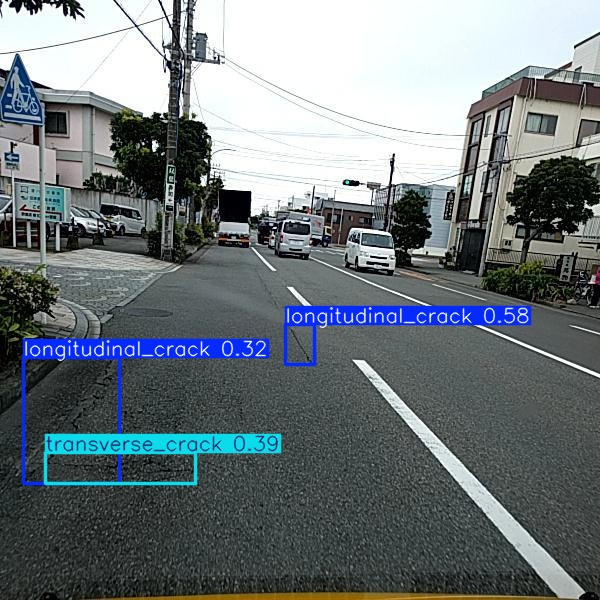

In [21]:
from IPython.display import Image, display
from pathlib import Path

for p in Path("runs/detect").rglob("pothole.jpg"):
    display(Image(filename=str(p)))

In [22]:
result = results[0]

for box in result.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    print(
        f"{result.names[cls]}: "
        f"{conf:.3f}"
    )

longitudinal_crack: 0.584
transverse_crack: 0.388
longitudinal_crack: 0.317


In [1]:
import shutil

SOURCE_MODEL = Path(
    "/kaggle/working/civiceye_training/"
    "yolov8n_rdd2022_640/weights/best.pt"
)

CIVICEYE_MODEL = Path(
    "/kaggle/working/civiceye_rdd2022_best.pt"
)

shutil.copy2(SOURCE_MODEL, CIVICEYE_MODEL)

print("CivicEye model:")
print(CIVICEYE_MODEL)
print("Size:", round(CIVICEYE_MODEL.stat().st_size / 1024**2, 2), "MB")

NameError: name 'Path' is not defined

In [9]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)
print("Model device:", next(model.parameters()).device)

CUDA available: True
Device: cuda
Model device: cuda:0


In [10]:
print(DEVICE)
print(next(model.parameters()).device)

cuda
cuda:0


In [11]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.models import (
    mobilenet_v2, MobileNet_V2_Weights,
    resnet18, ResNet18_Weights
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0).to(DEVICE)

In [12]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class RoadDataset(Dataset):

    def __init__(self, split):

        self.image_dir = DATASET_ROOT / split / "images"
        self.label_dir = DATASET_ROOT / split / "labels"

        self.samples = []

        for img in sorted(self.image_dir.glob("*.jpg")):

            label_file = self.label_dir / f"{img.stem}.txt"

            if not label_file.exists():
                continue

            tokens = label_file.read_text().split()

            # Skip images with no annotations
            if len(tokens) == 0:
                continue

            # Keep only valid 5 classes
            cls = int(tokens[0])
            if cls not in [0, 1, 2, 3, 4]:
                continue

            self.samples.append((img, cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, cls = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        image = transform(image)

        return image, cls


train_dataset = RoadDataset("train")
val_dataset = RoadDataset("val")

train_loader = DataLoader(
    train_dataset,
    batch_size=128,      # was 64
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

# Check labels present
labels = sorted(set(cls for _, cls in train_dataset.samples))
print("Classes:", labels)

Train: 18772
Val: 3921
Classes: [0, 1, 2, 3, 4]


In [13]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn

model = mobilenet_v2(
    weights=MobileNet_V2_Weights.IMAGENET1K_V1
)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Fine-tune only the last 3 blocks
for param in model.features[-3:].parameters():
    param.requires_grad = True

# 5 output classes
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280, 5)
)

model = model.to(DEVICE)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [14]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

for epoch in range(10):

    model.train()
    running_loss = 0

    for imgs, labels in train_loader:

        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/10  Loss: {avg_loss:.4f}")

Epoch 1/10  Loss: 1.1514
Epoch 2/10  Loss: 0.9670
Epoch 3/10  Loss: 0.8776
Epoch 4/10  Loss: 0.8005
Epoch 5/10  Loss: 0.7217
Epoch 6/10  Loss: 0.6341
Epoch 7/10  Loss: 0.5404
Epoch 8/10  Loss: 0.4438
Epoch 9/10  Loss: 0.3464
Epoch 10/10  Loss: 0.2520


In [15]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

pred = []
true = []

with torch.no_grad():

    for imgs, labels in val_loader:

        outputs = model(imgs.to(DEVICE))

        p = outputs.argmax(1).cpu().numpy()

        pred.extend(p)
        true.extend(labels.numpy())

accuracy = accuracy_score(true, pred)
weighted_f1 = f1_score(true, pred, average="weighted")

print("="*50)
print(f"Accuracy     : {accuracy:.4f}")
print(f"Weighted F1  : {weighted_f1:.4f}")
print("="*50)

print(classification_report(
    true,
    pred,
    target_names=["D00","D10","D20","D40","D43"]
))

Accuracy     : 0.6348
Weighted F1  : 0.6260
              precision    recall  f1-score   support

         D00       0.69      0.75      0.72      1441
         D10       0.60      0.33      0.43       544
         D20       0.54      0.61      0.58       774
         D40       0.66      0.73      0.70       808
         D43       0.57      0.45      0.50       354

    accuracy                           0.63      3921
   macro avg       0.61      0.58      0.58      3921
weighted avg       0.63      0.63      0.63      3921



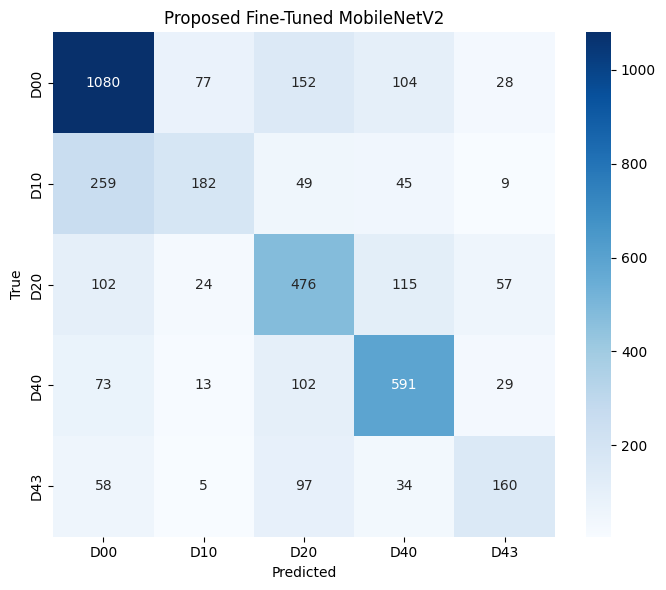

,Method,Accuracy,Weighted F1
0,Base Paper (India Subset),0.780000,NaN
1,Proposed Fine-Tuned MobileNetV2,0.634787,0.626009


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm = confusion_matrix(true, pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["D00","D10","D20","D40","D43"],
    yticklabels=["D00","D10","D20","D40","D43"]
)

plt.title("Proposed Fine-Tuned MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)
plt.show()

benchmark = pd.DataFrame({
    "Method": [
        "Base Paper (India Subset)",
        "Proposed Fine-Tuned MobileNetV2"
    ],
    "Accuracy": [0.78, accuracy],
    "Weighted F1": [None, weighted_f1]
})

benchmark

In [17]:
from sklearn.metrics import accuracy_score, f1_score

# Keep only the 4 classes used in the paper
keep = [i for i, y in enumerate(true) if y != 4]

true4 = [true[i] for i in keep]
pred4 = [pred[i] for i in keep]

acc4 = accuracy_score(true4, pred4)
f14 = f1_score(true4, pred4, average="weighted")

print("4-Class Accuracy :", round(acc4,4))
print("4-Class F1       :", round(f14,4))

4-Class Accuracy : 0.6529
4-Class F1       : 0.6554
